In [1]:
%pip install torchvision

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as colormap
import importlib
import src.data.data_loader_stroke as dl
importlib.reload(dl)
import importlib
import src.model.model_stroke as md
importlib.reload(md)
import src.model.train_utils_stroke as tu
importlib.reload(tu)
import src.utils.helpers as hp
importlib.reload(hp)
from src.model.train_utils_stroke import set_seed, train_model
from src.model.model_stroke import build_model_a, build_model_b, count_params
from src.data.data_loader_stroke import get_loaders
from PIL import Image
from src.data.data_loader_stroke import val_transform, DATA_ROOT
import random
import sys
sys.path.append('..')
import torch.nn as nn
from pathlib import Path

from src.data.data_loader_stroke import (get_loaders, BINARY_CLASSES,
                                   STROKE_CLASSES, SEED)
from src.model.model_stroke import build_model_a, build_model_b, count_params
from src.model.train_utils_stroke import set_seed, train_model
from src.utils.helpers import plot_history, evaluate_model, show_gradcam_grid

In [ ]:
# ─── Config ─────────────────────────────────────────────
cfg = get_config('Stroke')
paths = get_paths('Stroke')
manager = get_output_manager('Stroke')

DEVICE   = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
MODEL_DIR = manager.paths['weights']
MODEL_DIR.mkdir(parents=True, exist_ok=True)

MODEL_A_PATH = MODEL_DIR / Path(cfg['paths']['weights_a']).name
MODEL_B_PATH = MODEL_DIR / Path(cfg['paths']['weights_b']).name

dl.DATA_ROOT    = Path(cfg['paths']['data_root']).resolve()
dl.BATCH_SIZE   = int(cfg['data']['batch_size'])
dl.VAL_SPLIT    = float(cfg['data']['val_split'])
dl.SEED         = int(cfg['data'].get('seed', 42))

LR       = float(cfg['model_a']['learning_rate'])
PATIENCE = int(cfg['model_a']['patience'])
EPOCHS_A = int(cfg['model_a']['epochs'])
EPOCHS_B = int(cfg['model_b']['epochs'])

manager.print_structure()
print(f'✅ Device : {DEVICE}')
print(f'✅ Classes binaires   : {BINARY_CLASSES}')
print(f'✅ Classes stroke     : {STROKE_CLASSES}')



✅ Device : cpu
✅ Classes binaires   : ['Normal', 'Stroke']
✅ Classes stroke     : ['Bleeding', 'Ischemia']


In [ ]:
# Vérification du chemin utilisé
print(f'DATA_ROOT utilisé : {dl.DATA_ROOT}')
print(f'Existe ? : {dl.DATA_ROOT.exists()}')
print()

print('📂 Chargement des données...\n')
train_loader_a, val_loader_a, test_loader_a = get_loaders('binary')
print()
train_loader_b, val_loader_b, test_loader_b = get_loaders('multiclass')

DATA_ROOT utilisé : C:\stroke-cnn-project\data\Brain_Stroke_CT_Dataset
Existe ? : True

📂 Chargement des données...

[Dataset: binary]
  Train :  4656 images
  Val   :   997 images
  Test  :   997 images

[Dataset: multiclass]
  Train :  1557 images
  Val   :   333 images
  Test  :   333 images


In [ ]:
# ─── Cellule 3 : Construction des modèles ───────────────
model_a = build_model_a()
model_b = build_model_b()

print(f'Model A (EfficientNet-B0) : {count_params(model_a):,} paramètres')
print(f'Model B (ResNet-50)       : {count_params(model_b):,} paramètres')
print('\n✅ Modèles construits avec succès !')

Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to C:\Users\user/.cache\torch\hub\checkpoints\efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:03<00:00, 6.26MB/s]


Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to C:\Users\user/.cache\torch\hub\checkpoints\resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:17<00:00, 5.94MB/s]

Model A (EfficientNet-B0) : 740,610 paramètres
Model B (ResNet-50)       : 24,033,090 paramètres

✅ Modèles construits avec succès !


In [ ]:
# ─── Cellule 4 : Entraînement Model A ───────────────────
set_seed(SEED)

model_a, history_a = train_model(
    model        = model_a,
    train_loader = train_loader_a,
    val_loader   = val_loader_a,
    epochs       = EPOCHS_A,
    save_path    = MODEL_A_PATH,
    model_name   = 'Model A — Normal vs Stroke',
    DEVICE       = DEVICE,
    LR           = LR,
    PATIENCE     = PATIENCE
)


  Training : Model A — Normal vs Stroke
  Device   : cpu
Epoch   1/20  train_loss=0.5949  train_acc=0.683  val_loss=0.5382  val_acc=0.752  ✓ saved
Epoch   2/20  train_loss=0.4887  train_acc=0.774  val_loss=0.4675  val_acc=0.792  ✓ saved
Epoch   3/20  train_loss=0.4494  train_acc=0.797  val_loss=0.4346  val_acc=0.816  ✓ saved
Epoch   4/20  train_loss=0.4348  train_acc=0.805  val_loss=0.4136  val_acc=0.825  ✓ saved
Epoch   5/20  train_loss=0.4169  train_acc=0.810  val_loss=0.4008  val_acc=0.826  ✓ saved
Epoch   6/20  train_loss=0.4058  train_acc=0.817  val_loss=0.3976  val_acc=0.827  ✓ saved
Epoch   7/20  train_loss=0.3995  train_acc=0.826  val_loss=0.3775  val_acc=0.843  ✓ saved
Epoch   8/20  train_loss=0.3937  train_acc=0.823  val_loss=0.3773  val_acc=0.843  ✓ saved
Epoch   9/20  train_loss=0.3918  train_acc=0.828  val_loss=0.3668  val_acc=0.847  ✓ saved
Epoch  10/20  train_loss=0.3854  train_acc=0.830  val_loss=0.3537  val_acc=0.860  ✓ saved
Epoch  11/20  train_loss=0.3799  train_acc

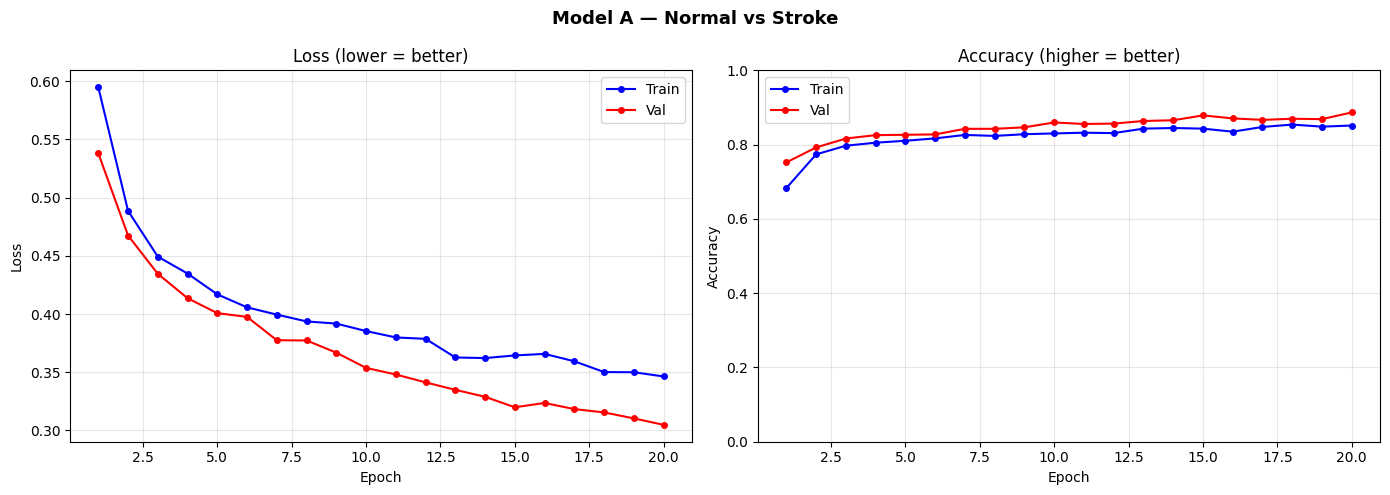

In [ ]:
from src.utils.helpers import plot_history, evaluate_model

plot_history(history_a, title='Model A — Normal vs Stroke')

  Model A — Normal vs Stroke
  Accuracy : 90.17%
  AUC Score : 0.8832

              precision    recall  f1-score   support

      Normal       0.92      0.94      0.93       669
      Stroke       0.87      0.83      0.85       328

    accuracy                           0.90       997
   macro avg       0.89      0.88      0.89       997
weighted avg       0.90      0.90      0.90       997



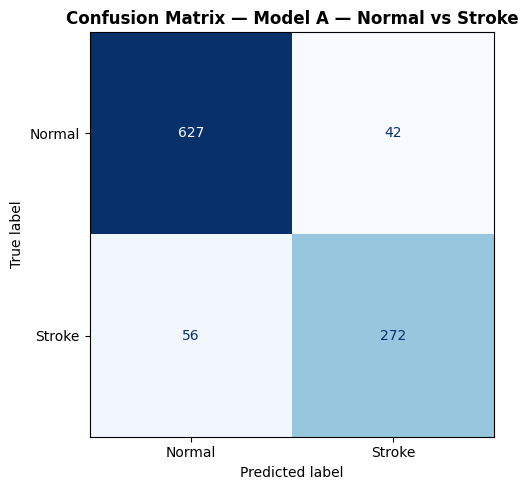

(array([0, 1, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0,
        0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0,
        0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 1, 1,
        0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0,
        0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0,
        0, 1, 0, 0, 1, 0, 1, 1, 0, 0, 0, 1, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0,
        0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 1, 0, 1,
        1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0,
        1, 1, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 1, 0,
        1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 1,
        1, 1, 0, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1,
        1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 1, 0, 1, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0,
        1, 1, 1, 0, 0, 1, 0, 1, 0, 0, 

In [8]:
evaluate_model(
    model_a, test_loader_a,
    BINARY_CLASSES,
    'Model A — Normal vs Stroke',
    DEVICE
)

In [9]:
set_seed(SEED)

model_b, history_b = train_model(
    model        = model_b,
    train_loader = train_loader_b,
    val_loader   = val_loader_b,
    epochs       = EPOCHS_B,
    save_path    = MODEL_B_PATH,
    model_name   = 'Model B — Bleeding vs Ischemia',
    DEVICE       = DEVICE,
    LR           = LR,
    PATIENCE     = PATIENCE
)


  Training : Model B — Bleeding vs Ischemia
  Device   : cpu
Epoch   1/25  train_loss=0.4523  train_acc=0.784  val_loss=0.3320  val_acc=0.865  ✓ saved
Epoch   2/25  train_loss=0.2403  train_acc=0.908  val_loss=0.1741  val_acc=0.940  ✓ saved
Epoch   3/25  train_loss=0.1938  train_acc=0.921  val_loss=0.1925  val_acc=0.931
Epoch   4/25  train_loss=0.1523  train_acc=0.945  val_loss=0.2374  val_acc=0.892
Epoch   5/25  train_loss=0.1088  train_acc=0.960  val_loss=0.1518  val_acc=0.955  ✓ saved
Epoch   6/25  train_loss=0.1264  train_acc=0.951  val_loss=0.1237  val_acc=0.955  ✓ saved
Epoch   7/25  train_loss=0.0987  train_acc=0.969  val_loss=0.1221  val_acc=0.967  ✓ saved
Epoch   8/25  train_loss=0.0977  train_acc=0.964  val_loss=0.1257  val_acc=0.958
Epoch   9/25  train_loss=0.0731  train_acc=0.974  val_loss=0.1217  val_acc=0.943  ✓ saved
Epoch  10/25  train_loss=0.0770  train_acc=0.976  val_loss=0.0939  val_acc=0.970  ✓ saved
Epoch  11/25  train_loss=0.0953  train_acc=0.967  val_loss=0.2019

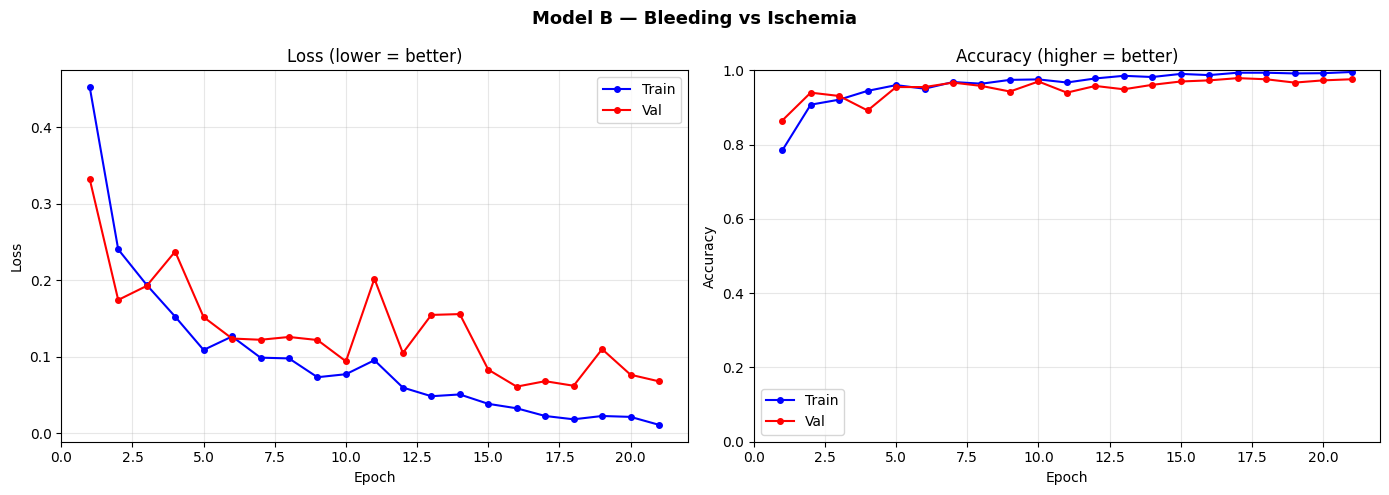

  Model B — Bleeding vs Ischemia
  Accuracy : 97.30%
  AUC Score : 0.9728

              precision    recall  f1-score   support

    Bleeding       0.97      0.98      0.97       174
    Ischemia       0.97      0.97      0.97       159

    accuracy                           0.97       333
   macro avg       0.97      0.97      0.97       333
weighted avg       0.97      0.97      0.97       333



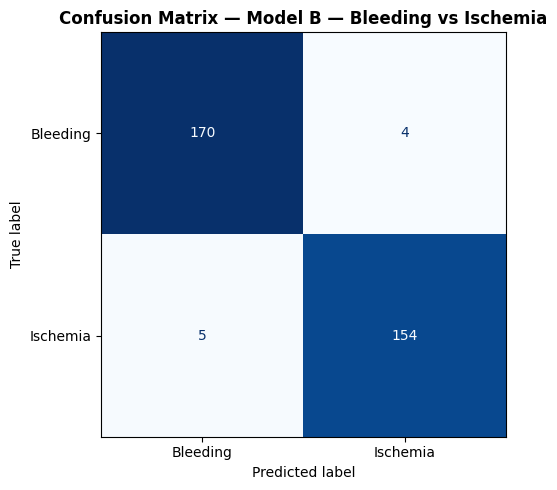

(array([0, 1, 1, 0, 1, 1, 0, 0, 1, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 1, 1, 0,
        0, 1, 0, 1, 1, 0, 1, 1, 1, 0, 0, 0, 0, 1, 1, 0, 1, 0, 1, 1, 1, 0,
        0, 1, 0, 1, 1, 1, 1, 1, 1, 0, 0, 1, 0, 1, 1, 1, 0, 0, 0, 1, 0, 0,
        0, 1, 1, 0, 1, 1, 0, 1, 0, 0, 1, 1, 1, 1, 0, 0, 0, 1, 0, 1, 0, 1,
        0, 0, 1, 0, 0, 0, 0, 1, 0, 1, 0, 1, 1, 0, 0, 0, 0, 1, 1, 0, 0, 1,
        1, 1, 0, 1, 1, 1, 0, 0, 0, 1, 0, 1, 1, 1, 1, 0, 1, 1, 0, 0, 0, 1,
        0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1,
        1, 1, 1, 0, 0, 0, 1, 0, 1, 1, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 1,
        0, 0, 0, 1, 1, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1,
        0, 1, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 1,
        0, 0, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 0, 0,
        1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 1, 0, 1, 0, 0,
        1, 0, 1, 1, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 1, 0, 0, 1,
        1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 

In [10]:
plot_history(history_b, title='Model B — Bleeding vs Ischemia')

evaluate_model(
    model_b, test_loader_b,
    STROKE_CLASSES,
    'Model B — Bleeding vs Ischemia',
    DEVICE
)

c:\stroke-cnn-project\notebooks\..\src\model\model.py:95: UserWarning: Full backward hook is firing when gradients are computed with respect to module outputs since no inputs require gradients. See https://docs.pytorch.org/docs/main/generated/torch.nn.Module.html#torch.nn.Module.register_full_backward_hook for more details.
  output[0, class_idx].backward()


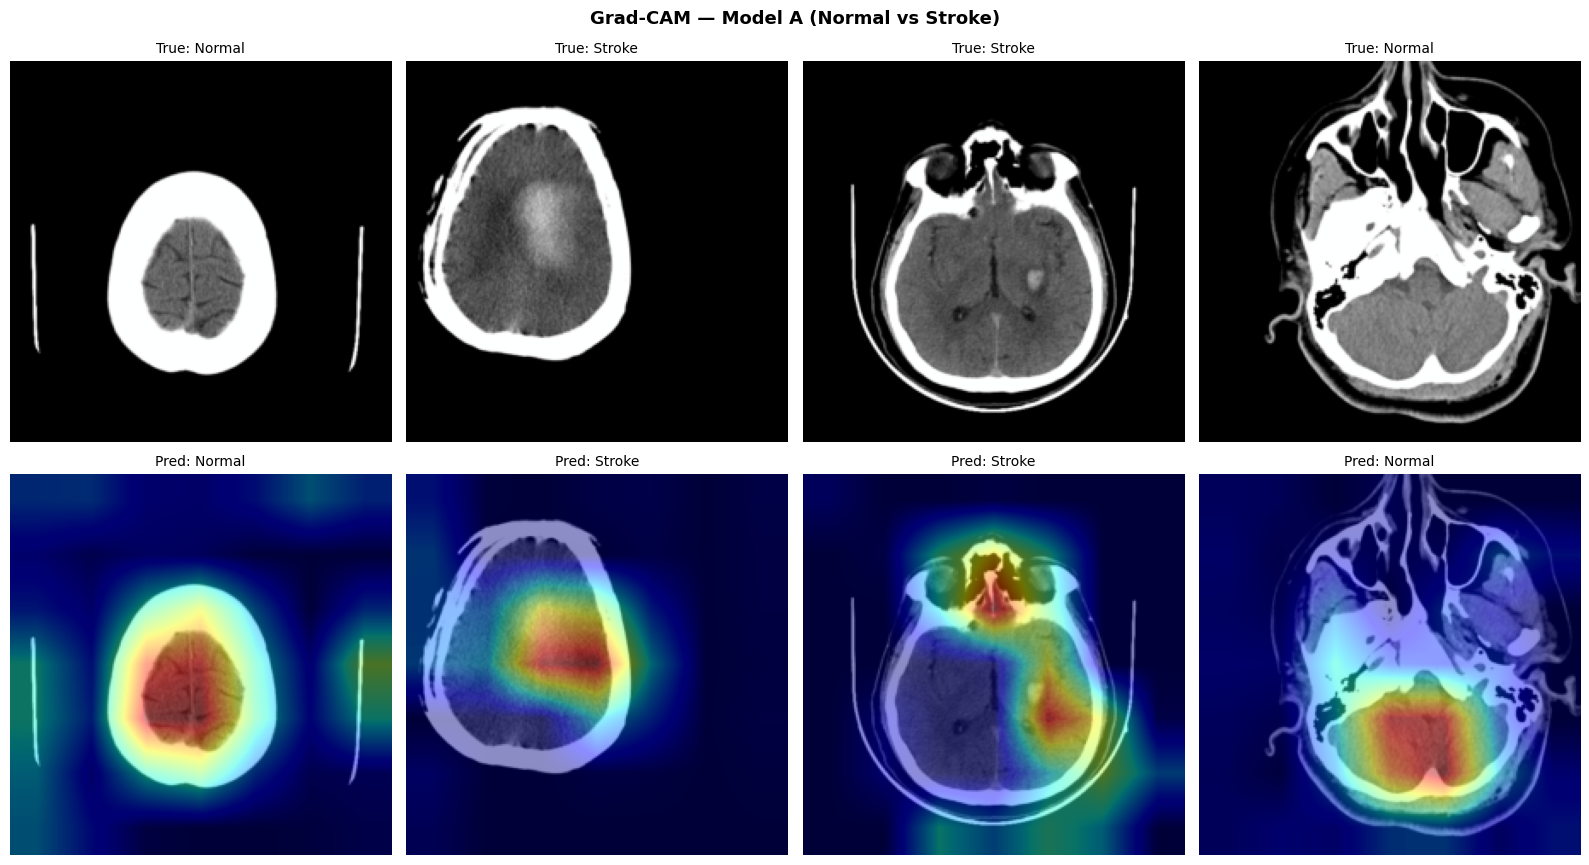

In [ ]:
from src.model.model_stroke import GradCAM

show_gradcam_grid(
    model        = model_a,
    target_layer = model_a.features[-1],
    loader       = test_loader_a,
    class_names  = BINARY_CLASSES,
    title        = 'Grad-CAM — Model A (Normal vs Stroke)',
    device       = DEVICE,
    GradCAM      = GradCAM,
    n            = 4
)

In [ ]:
from src.data.data_loader_stroke import val_transform, DATA_ROOT
from src.utils.helpers import predict_single
import random

# Prendre des images aléatoires du test set
test_imgs = list((DATA_ROOT / 'Normal' / 'PNG').glob('*.png')) + \
            list((DATA_ROOT / 'Bleeding' / 'PNG').glob('*.png')) + \
            list((DATA_ROOT / 'Ischemia' / 'PNG').glob('*.png'))

sample_imgs = random.sample(test_imgs, 5)

for img_path in sample_imgs:
    result = predict_single(
        image_path           = img_path,
        model_a              = model_a,
        model_b              = model_b,
        val_transform        = val_transform,
        DEVICE               = DEVICE,
        BINARY_CLASSES       = BINARY_CLASSES,
        STROKE_CLASSES       = STROKE_CLASSES,
        CONFIDENCE_THRESHOLD = 0.85,
        threshold            = 0.5
    )
    print(f'Image      : {img_path.parent.parent.name}')
    print(f'Résultat   : {result["message"]}')
    print()

Image      : Bleeding
Résultat   : ⚠️ Confiance faible (81.9%) — consulter un radiologue

Image      : Normal
Résultat   : ✅ Cerveau Normal (confiance: 93.4%)

Image      : Normal
Résultat   : ✅ Cerveau Normal (confiance: 88.6%)

Image      : Ischemia
Résultat   : ⚠️ Confiance faible (67.7%) — consulter un radiologue

Image      : Normal
Résultat   : ✅ Cerveau Normal (confiance: 98.4%)



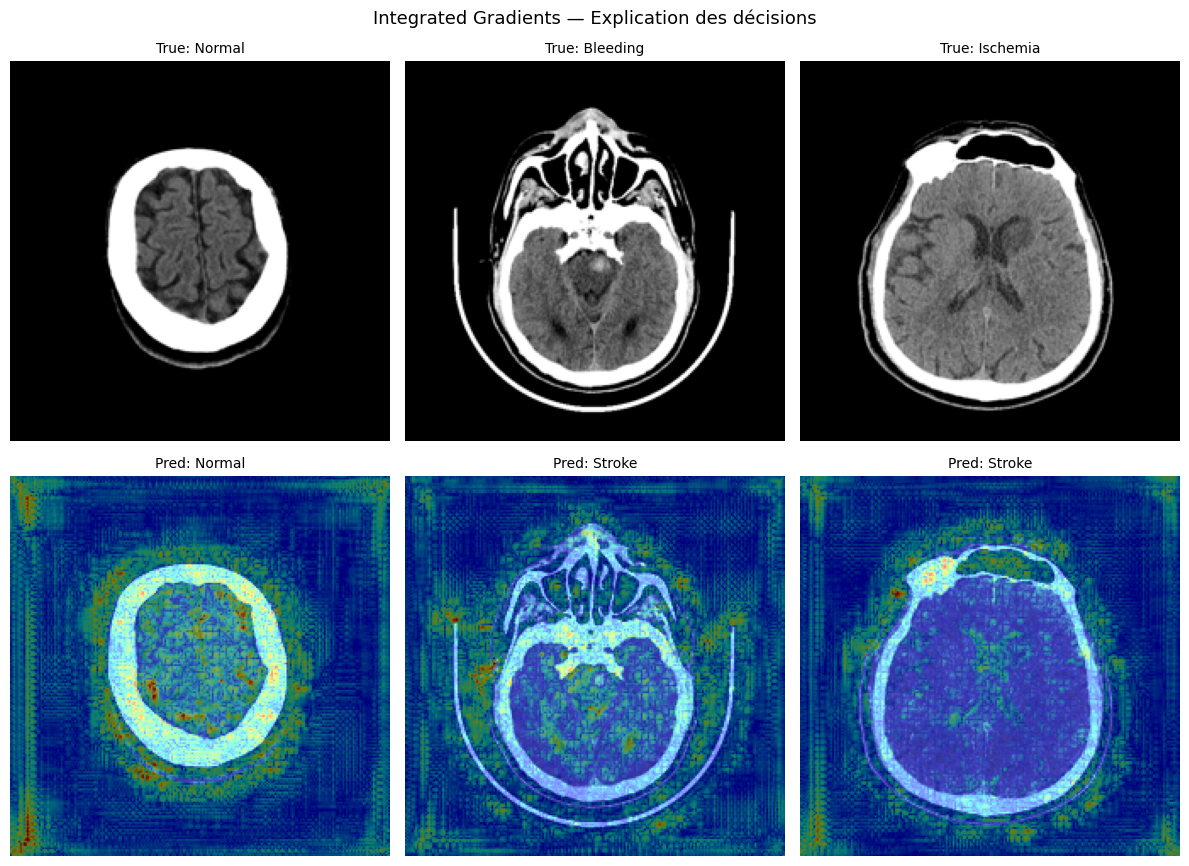

In [ ]:

def integrated_gradients(model, image_tensor, device, steps=50):
    model.eval()
    img      = image_tensor.to(device)
    baseline = torch.zeros_like(img).to(device)
    
    integrated_grads = torch.zeros_like(img)
    
    for step in range(steps):
        alpha        = step / steps
        interpolated = baseline + alpha * (img - baseline)
        interpolated = interpolated.detach().requires_grad_(True)
        
        output     = model(interpolated)
        pred_class = output.argmax(dim=1).item()
        
        model.zero_grad()
        output[0, pred_class].backward()
        
        integrated_grads += interpolated.grad.detach()
    
    integrated_grads = integrated_grads / steps
    integrated_grads = integrated_grads * (img - baseline)
    
    attr = integrated_grads.squeeze().cpu().detach()
    attr = attr.permute(1, 2, 0).numpy()
    attr = np.mean(np.abs(attr), axis=2)
    attr = (attr - attr.min()) / (attr.max() - attr.min() + 1e-8)
    
    return attr, pred_class


def show_ig_grid(model, class_names, data_root, device, n=3):
    
    # ── Une image par classe ─────────────────────────────
    all_imgs = []
    for cls in ['Normal', 'Bleeding', 'Ischemia']:
        folder = data_root / cls / 'PNG'
        if folder.exists():
            imgs = list(folder.glob('*.png'))
            if imgs:
                all_imgs.append((random.choice(imgs), cls))
    
    all_imgs  = all_imgs[:n]
    n_actual  = len(all_imgs)
    
    fig, axes = plt.subplots(2, n_actual, figsize=(4 * n_actual, 9))
    if n_actual == 1:
        axes = axes.reshape(2, 1)
    
    for i, (img_path, true_class) in enumerate(all_imgs):
        image  = Image.open(img_path).convert('RGB')
        tensor = val_transform(image).unsqueeze(0)
        
        attr, pred_idx = integrated_gradients(model, tensor, device, steps=50)
        
        img_np = np.array(image.resize((224, 224))) / 255.0
        
        # ── Contraste heatmap ────────────────────────────
        attr = np.power(attr, 0.4)
        attr = (attr - attr.min()) / (attr.max() - attr.min() + 1e-8)
        
        heat    = colormap.jet(attr)[:, :, :3]
        overlay = (0.5 * img_np + 0.5 * heat).clip(0, 1)
        
        axes[0, i].imshow(img_np, cmap='gray')
        axes[0, i].set_title(f'True: {true_class}', fontsize=10)
        axes[0, i].axis('off')
        
        axes[1, i].imshow(overlay)
        axes[1, i].set_title(f'Pred: {class_names[pred_idx]}', fontsize=10)
        axes[1, i].axis('off')
    
    axes[0, 0].set_ylabel('Image originale', fontsize=11)
    axes[1, 0].set_ylabel('Integrated Gradients', fontsize=11)
    plt.suptitle('Integrated Gradients — Explication des décisions', fontsize=13)
    plt.tight_layout()
    plt.show()


# ── Lancer ───────────────────────────────────────────────
show_ig_grid(
    model       = model_a,
    class_names = BINARY_CLASSES,
    data_root   = DATA_ROOT,
    device      = DEVICE,
    n           = 3
)